In [1]:
from matplotlib.colors import ListedColormap, to_rgb
import numpy as np
import matplotlib.pyplot as plt
import os

classes = {0: "road", 1: "sidewalk", 2: "building", 3: "wall", 4: "fence", 5: "pole", 
        6: "traffic light", 7: "traffic sign", 8: "vegetation", 9: "terrain", 10: "sky", 11: "person", 
        12: "rider", 13: "car", 14: "truck", 15: "bus", 16: "train", 17: "motorcycle", 18: "bicycle", 19: "others"}
##FFFFFF
color_mapping = {
    #Flat surfaces
    "road": "#666666", "sidewalk": "#282828",
    #Construction
    "building": "#FF3232", "wall" : "#6a329f", "fence": "#FFC1C1",
    #Objects / infrastructure
    "pole": "#523415", "traffic light": "#FFFF66", "traffic sign": "#FFFF00",
    #Nature
    "vegetation": "#008000", "terrain": "#6BAF6B",
    #Sky
    "sky": "#00b1ff",
    #Humans
    "person": "#E8BEAC", "rider": "#ac95e1",
    #Vehicle
    "car": "#FFA500", "truck": "#B07A15", "bus": "#604107", "train": "#3A2908", "motorcycle": "#EDC1E6", "bicycle": "#BEDFE5",
    #other:
    "others": "#E5ACB6"
}

colors = []
for i in sorted(classes.keys()):
    class_name = classes[i]
    colors.append(to_rgb(color_mapping[class_name]))

config_cmap = ListedColormap(colors)

Scanning 2975 masks in /users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/train/label
  500/2975
  1000/2975
  1500/2975
  2000/2975
  2500/2975


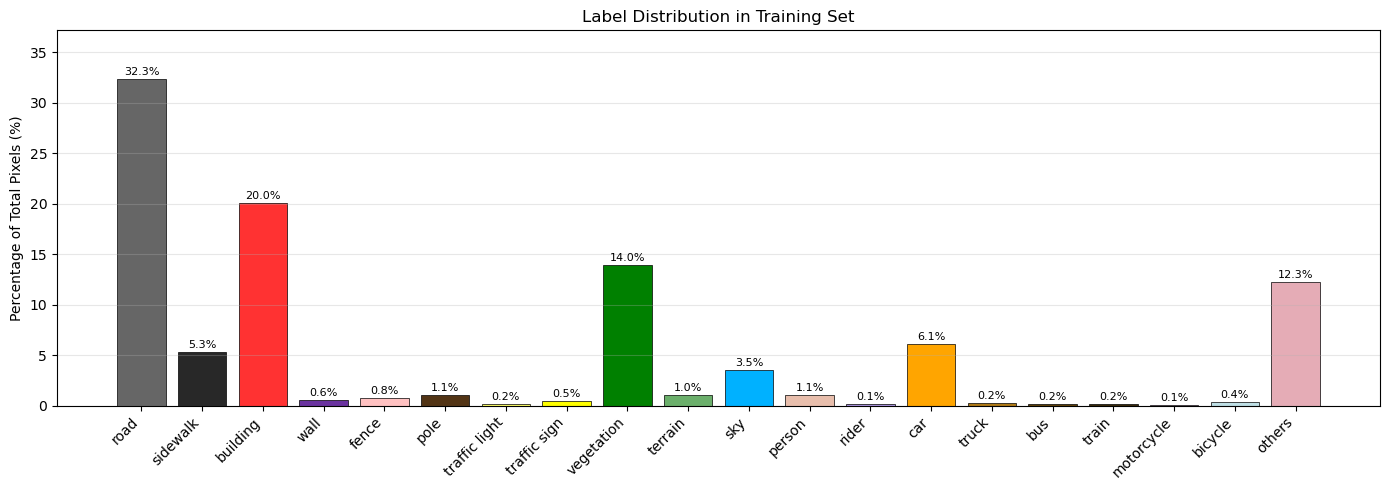

In [2]:

LABEL_DIR = "/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/train/label"
NUM_CLASSES = 20  # 0..18 + 19 (others)

files = sorted(f for f in os.listdir(LABEL_DIR) if f.endswith(".npy"))
print(f"Scanning {len(files)} masks in {LABEL_DIR}")

counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for i, fname in enumerate(files):
    m = np.load(os.path.join(LABEL_DIR, fname))
    m = np.where(m == -1, 19, m).astype(np.int64)
    binc = np.bincount(m.ravel(), minlength=NUM_CLASSES)
    counts += binc[:NUM_CLASSES]
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(files)}")

total = counts.sum()
percents = counts / total * 100

names = [classes[i] for i in range(NUM_CLASSES)]
bar_colors = [color_mapping[n] for n in names]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, percents, color=bar_colors, edgecolor="black", linewidth=0.5)

for bar, pct in zip(bars, percents):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Percentage of Total Pixels (%)")
ax.set_title("Label Distribution in Training Set")
ax.set_ylim(0, max(percents) * 1.15)
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Scanning 500 masks in /users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/val/label
  500/500


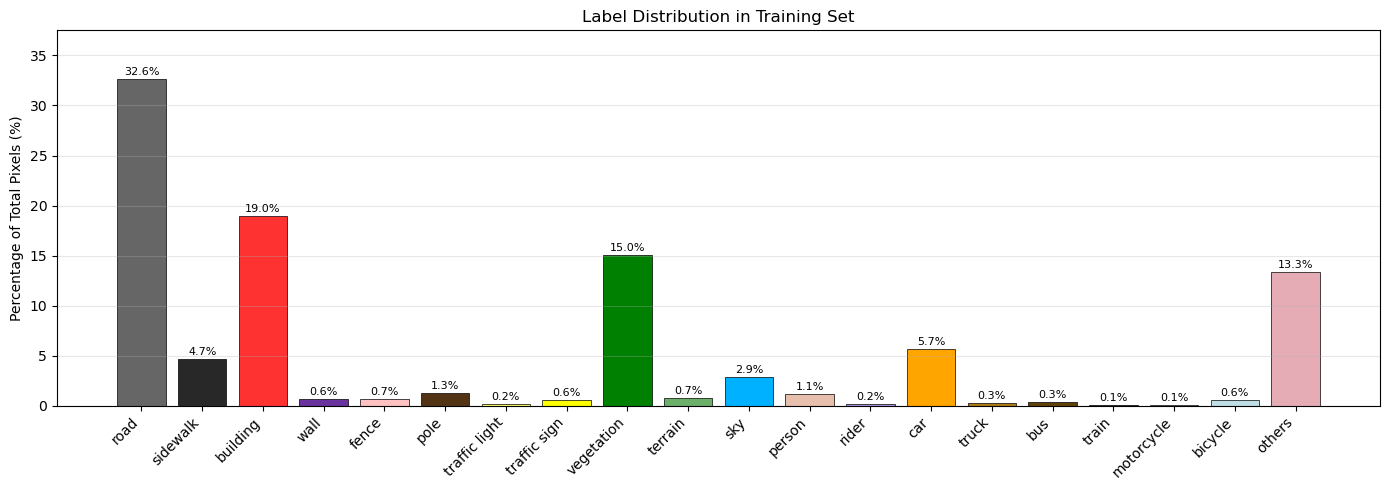

In [3]:

LABEL_DIR = "/users/PGS0404/atran16/Desktop/CityScapeSegmentation/data/val/label"
NUM_CLASSES = 20  # 0..18 + 19 (others)

files = sorted(f for f in os.listdir(LABEL_DIR) if f.endswith(".npy"))
print(f"Scanning {len(files)} masks in {LABEL_DIR}")

counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for i, fname in enumerate(files):
    m = np.load(os.path.join(LABEL_DIR, fname))
    m = np.where(m == -1, 19, m).astype(np.int64)
    binc = np.bincount(m.ravel(), minlength=NUM_CLASSES)
    counts += binc[:NUM_CLASSES]
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{len(files)}")

total = counts.sum()
percents = counts / total * 100

names = [classes[i] for i in range(NUM_CLASSES)]
bar_colors = [color_mapping[n] for n in names]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(names, percents, color=bar_colors, edgecolor="black", linewidth=0.5)

for bar, pct in zip(bars, percents):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("Percentage of Total Pixels (%)")
ax.set_title("Label Distribution in Training Set")
ax.set_ylim(0, max(percents) * 1.15)
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
